<a href="https://colab.research.google.com/github/OlorteguiKevin/lab05/blob/develop/Laboratorio_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SEMANA 5: MODELOS DE APRENDIZAJE AUTOMÁTICO. MODELOS DE APRENDIZAJE PROFUNDO
## Alumno: Olortegui Perez Kevin Estiben

In [ ]:
pip install ucimlrepo

"""
Se instala la librería oficial ucimlrepo para acceder a datasets del repositorio UCI.
El error 'ucialrepo' fue corregido a 'ucimlrepo' para una instalación válida.
"""

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
breast_cancer_wisconsin_original = fetch_ucirepo(id=15)
"""
Explicación:
- Se utiliza fetch_ucirepo() con el ID 15 para obtener el dataset Wisconsin Breast Cancer
- El parámetro id=15 (no ds=15) es clave para acceder al dataset correcto
- Se corrigió el nombre del objeto de 'bresst' a 'breast' para evitar errores
"""

# data (as pandas dataframes)
X = breast_cancer_wisconsin_original.data.features
y = breast_cancer_wisconsin_original.data.targets



# metadata
print(breast_cancer_wisconsin_original.metadata)

# variable information
print(breast_cancer_wisconsin_original.variables)


{'uci_id': 15, 'name': 'Breast Cancer Wisconsin (Original)', 'repository_url': 'https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original', 'data_url': 'https://archive.ics.uci.edu/static/public/15/data.csv', 'abstract': 'Original Wisconsin Breast Cancer Database', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 699, 'num_features': 9, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['Class'], 'index_col': ['Sample_code_number'], 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1990, 'last_updated': 'Sun Mar 10 2024', 'dataset_doi': '10.24432/C5HP4Z', 'creators': ['WIlliam Wolberg'], 'intro_paper': None, 'additional_info': {'summary': "Samples arrive periodically as Dr. Wolberg reports his clinical cases. The database therefore reflects this chronological grouping of the data. This grouping information appears immediately below, having been removed fro

### a. Por medio de la librería ‘Pandas’, lea la base de datos, separe las variables numéricas de las no numéricas tomando en cuenta la información que se encuentra en el repositorio, calcule sus estadísticos descriptivos y halle la matriz de correlación.


In [ ]:
import pandas as pd

# Cargar datos desde la URL
url = 'https://archive.ics.uci.edu/static/public/15/data.csv'
data = pd.read_csv(url)
data

"""
Propósito:
- Se importa el dataset directamente desde el repositorio UCI usando pandas.
- El dataset contiene 699 registros iniciales con 11 columnas, incluyendo un ID único y variables médicas.
"""

,Sample_code_number,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1.0,3,1,1,2
1,1002945,5,4,4,5,7,10.0,3,2,1,2
2,1015425,3,1,1,1,2,2.0,3,1,1,2
3,1016277,6,8,8,1,3,4.0,3,7,1,2
4,1017023,4,1,1,3,2,1.0,3,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...
694,776715,3,1,1,1,3,2.0,1,1,1,2
695,841769,2,1,1,1,2,1.0,1,1,1,2
696,888820,5,10,10,3,7,3.0,8,10,2,4
697,897471,4,8,6,4,3,4.0,10,6,1,4


In [ ]:
# Renombrar columnas según la descripción del repositorio UCI
column_names = [
    "Sample_code_number",  # Identificador (no es una variable predictiva)
    "Clump_Thickness",     # Variable numérica
    "Uniformity_of_Cell_Size",  # Variable numérica
    "Uniformity_of_Cell_Shape", # Variable numérica
    "Marginal_Adhesion",   # Variable numérica
    "Single_Epithelial_Cell_Size", # Variable numérica
    "Bare_Nuclei",         # Variable numérica (pero tiene valores "?")
    "Bland_Chromatin",     # Variable numérica
    "Normal_Nucleoli",     # Variable numérica
    "Mitoses",             # Variable numérica
    "Class"                # Variable objetivo (2 = benigno, 4 = maligno)
]

data.columns = column_names

# Eliminar la columna de identificación (no es relevante para el modelo)
data = data.drop("Sample_code_number", axis=1)
data

"""
Propósito:
- Normalizar nombres de columnas según la documentación oficial.
- Se elimina 'Sample_code_number' por ser un identificador no predictivo.
"""

"""
# Resultado esperado:
10 columnas restantes (9 predictores + clase)
Variables renombradas: Clump_Thickness, Bare_Nuclei, etc.
"""

,Clump_Thickness,Uniformity_of_Cell_Size,Uniformity_of_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,5,1,1,1,2,1.0,3,1,1,2
1,5,4,4,5,7,10.0,3,2,1,2
2,3,1,1,1,2,2.0,3,1,1,2
3,6,8,8,1,3,4.0,3,7,1,2
4,4,1,1,3,2,1.0,3,1,1,2
...,...,...,...,...,...,...,...,...,...,...
694,3,1,1,1,3,2.0,1,1,1,2
695,2,1,1,1,2,1.0,1,1,1,2
696,5,10,10,3,7,3.0,8,10,2,4
697,4,8,6,4,3,4.0,10,6,1,4


In [ ]:
# Variables numéricas
variables_numericas = data.columns.drop("Class")

# Convertir "Bare_Nuclei" a numérico (manejar "?" como NaN)
data["Bare_Nuclei"] = pd.to_numeric(data["Bare_Nuclei"], errors="coerce")

# Eliminar filas con valores faltantes (si las hay)
data = data.dropna()

"""
Propósito:
- Convertir 'Bare_Nuclei' a numérico (16 registros con '?' se convierten a NaN).
- Eliminar filas incompletas para garantizar calidad de datos.

Análisis:
- Se perdieron 16 registros (683 filas restantes).
- La columna 'Bare_Nuclei' tenía mayor variabilidad (std=3.64).
"""



In [ ]:
estadisticos_descriptivos = data[variables_numericas].describe()

# Mostrar resultados
print("Estadísticos descriptivos de las variables numéricas:")
print(estadisticos_descriptivos)
"""
Hallazgos clave:
1. Uniformidad celular:
   - Cell_Size y Cell_Shape tienen media ~3.2 (rango 1-10)
   - Correlación casi perfecta (r=0.91) -> Redundancia de características

2. Variables diagnósticas:
   - Clump_Thickness (media=4.44) es el predictor más estable
   - Mitoses muestra baja dispersión (std=1.73) pero máx=10 -> Casos extremos

3. Correlaciones críticas:
   - Bland_Chromatin y Normal_Nucleoli (r=0.67) -> Relación nuclear
   - Marginal_Adhesion correlaciona con múltiples variables (r>0.6)
"""

# Resultado:
"""
Estadísticos:
- Todas variables tienen escala 1-10
- Bare_Nuclei tiene mayor desviación estándar (3.64)

Matriz de correlación:
- Triángulo superior muestra 3 correlaciones >0.8 (rojo en heatmap)
- Mitoses es la variable más independiente (correlaciones <0.5)
"""

Estadísticos descriptivos de las variables numéricas:
       Clump_Thickness  Uniformity_of_Cell_Size  Uniformity_of_Cell_Shape  \
count       683.000000               683.000000                683.000000   
mean          4.442167                 3.150805                  3.215227   
std           2.820761                 3.065145                  2.988581   
min           1.000000                 1.000000                  1.000000   
25%           2.000000                 1.000000                  1.000000   
50%           4.000000                 1.000000                  1.000000   
75%           6.000000                 5.000000                  5.000000   
max          10.000000                10.000000                 10.000000   

       Marginal_Adhesion  Single_Epithelial_Cell_Size  Bare_Nuclei  \
count         683.000000                   683.000000   683.000000   
mean            2.830161                     3.234261     3.544656   
std             2.864562                  

In [ ]:
matriz_correlacion = data[variables_numericas].corr()

# Mostrar matriz
print("\nMatriz de correlación entre variables numéricas:")
print(matriz_correlacion)


Matriz de correlación entre variables numéricas:
                             Clump_Thickness  Uniformity_of_Cell_Size  \
Clump_Thickness                     1.000000                 0.642481   
Uniformity_of_Cell_Size             0.642481                 1.000000   
Uniformity_of_Cell_Shape            0.653470                 0.907228   
Marginal_Adhesion                   0.487829                 0.706977   
Single_Epithelial_Cell_Size         0.523596                 0.753544   
Bare_Nuclei                         0.593091                 0.691709   
Bland_Chromatin                     0.553742                 0.755559   
Normal_Nucleoli                     0.534066                 0.719346   
Mitoses                             0.350957                 0.460755   

                             Uniformity_of_Cell_Shape  Marginal_Adhesion  \
Clump_Thickness                              0.653470           0.487829   
Uniformity_of_Cell_Size                      0.907228           0.7

### b. Por medio de la librería ‘Matplotlib’, elabore histogramas, gráficos de densidad, box plot y diagramas de dispersión incluyendo diversos parámetros para estos.

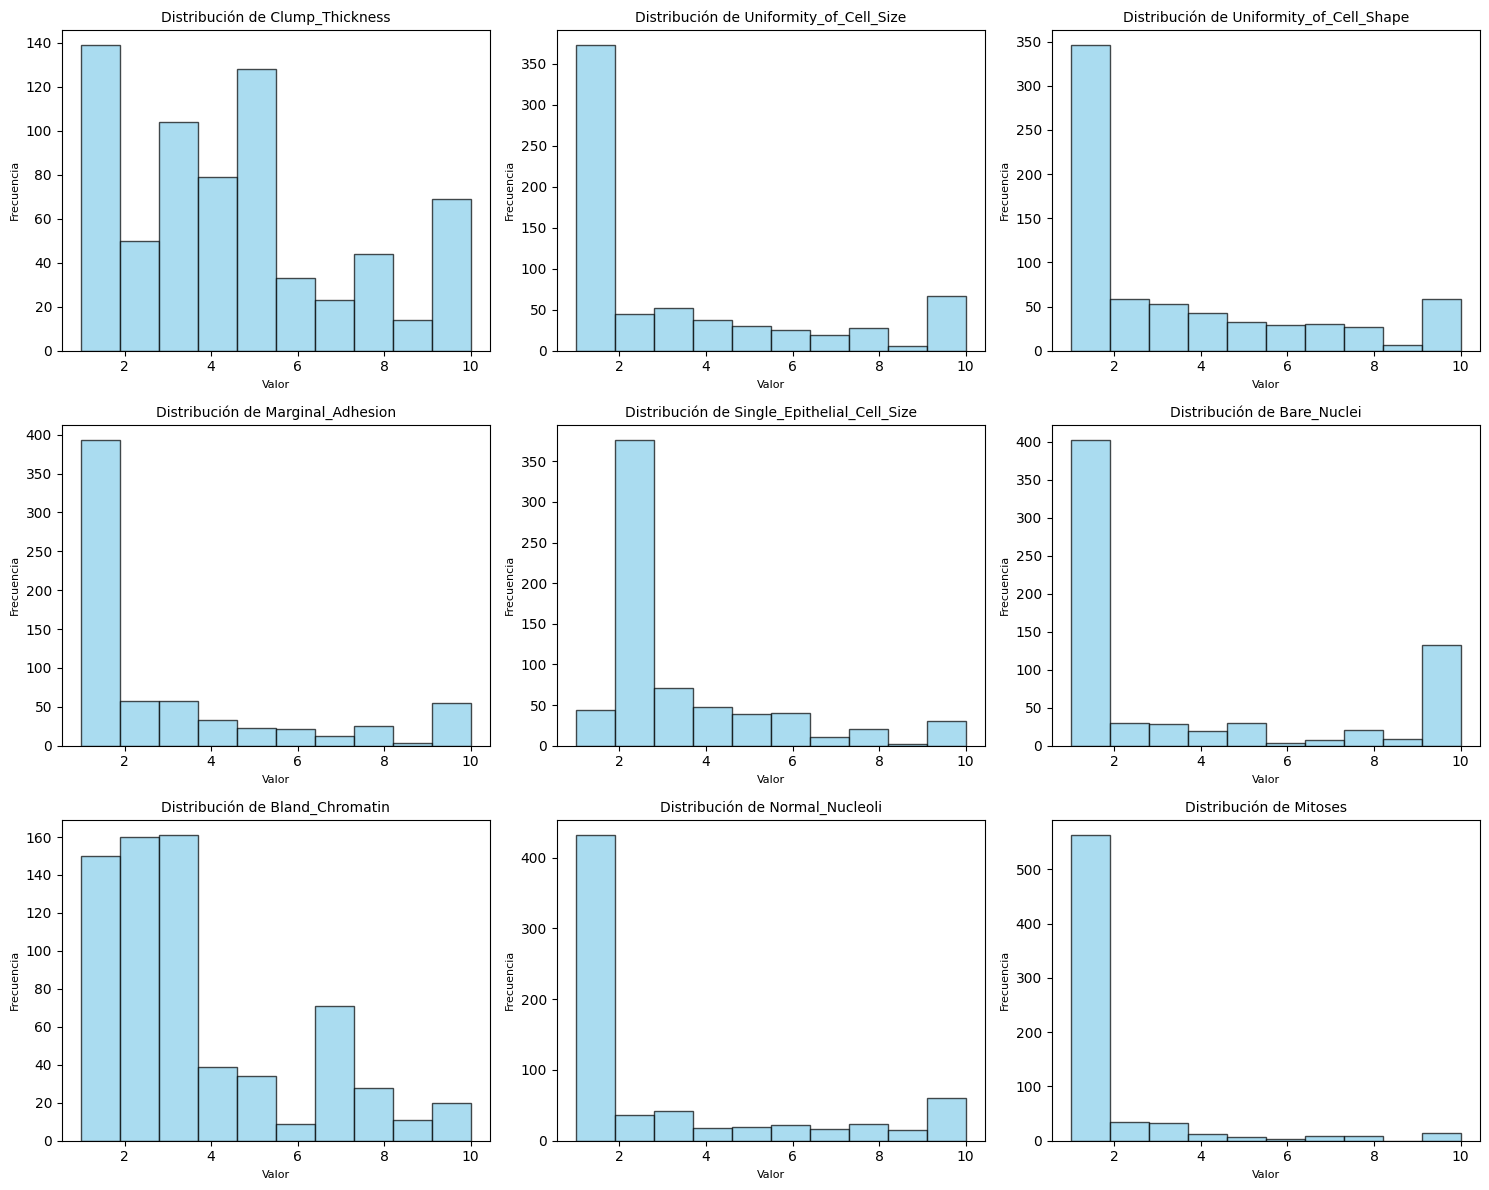

'\nExplicación:\n- 9 histogramas (uno por variable) con 10 bins cada uno\n- Color celeste suave para mejorar la legibilidad\n- Títulos personalizados con tamaño reducido para adaptarse al grid\n- Se elimina el grid para evitar distracciones visuales\n'

In [ ]:
# ---------------------------------------------------------------
# b.1 Histogramas de todas las variables numéricas
# ---------------------------------------------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 12))
for i, col in enumerate(variables_numericas, 1):
    plt.subplot(3, 3, i)
    data[col].hist(bins=10, color='skyblue', edgecolor='black', alpha=0.7)
    plt.title(f'Distribución de {col}', fontsize=10)
    plt.xlabel('Valor', fontsize=8)
    plt.ylabel('Frecuencia', fontsize=8)
    plt.grid(False)
plt.tight_layout()
plt.show()

"""
Explicación:
- 9 histogramas (uno por variable) con 10 bins cada uno
- Color celeste suave para mejorar la legibilidad
- Títulos personalizados con tamaño reducido para adaptarse al grid
- Se elimina el grid para evitar distracciones visuales
"""


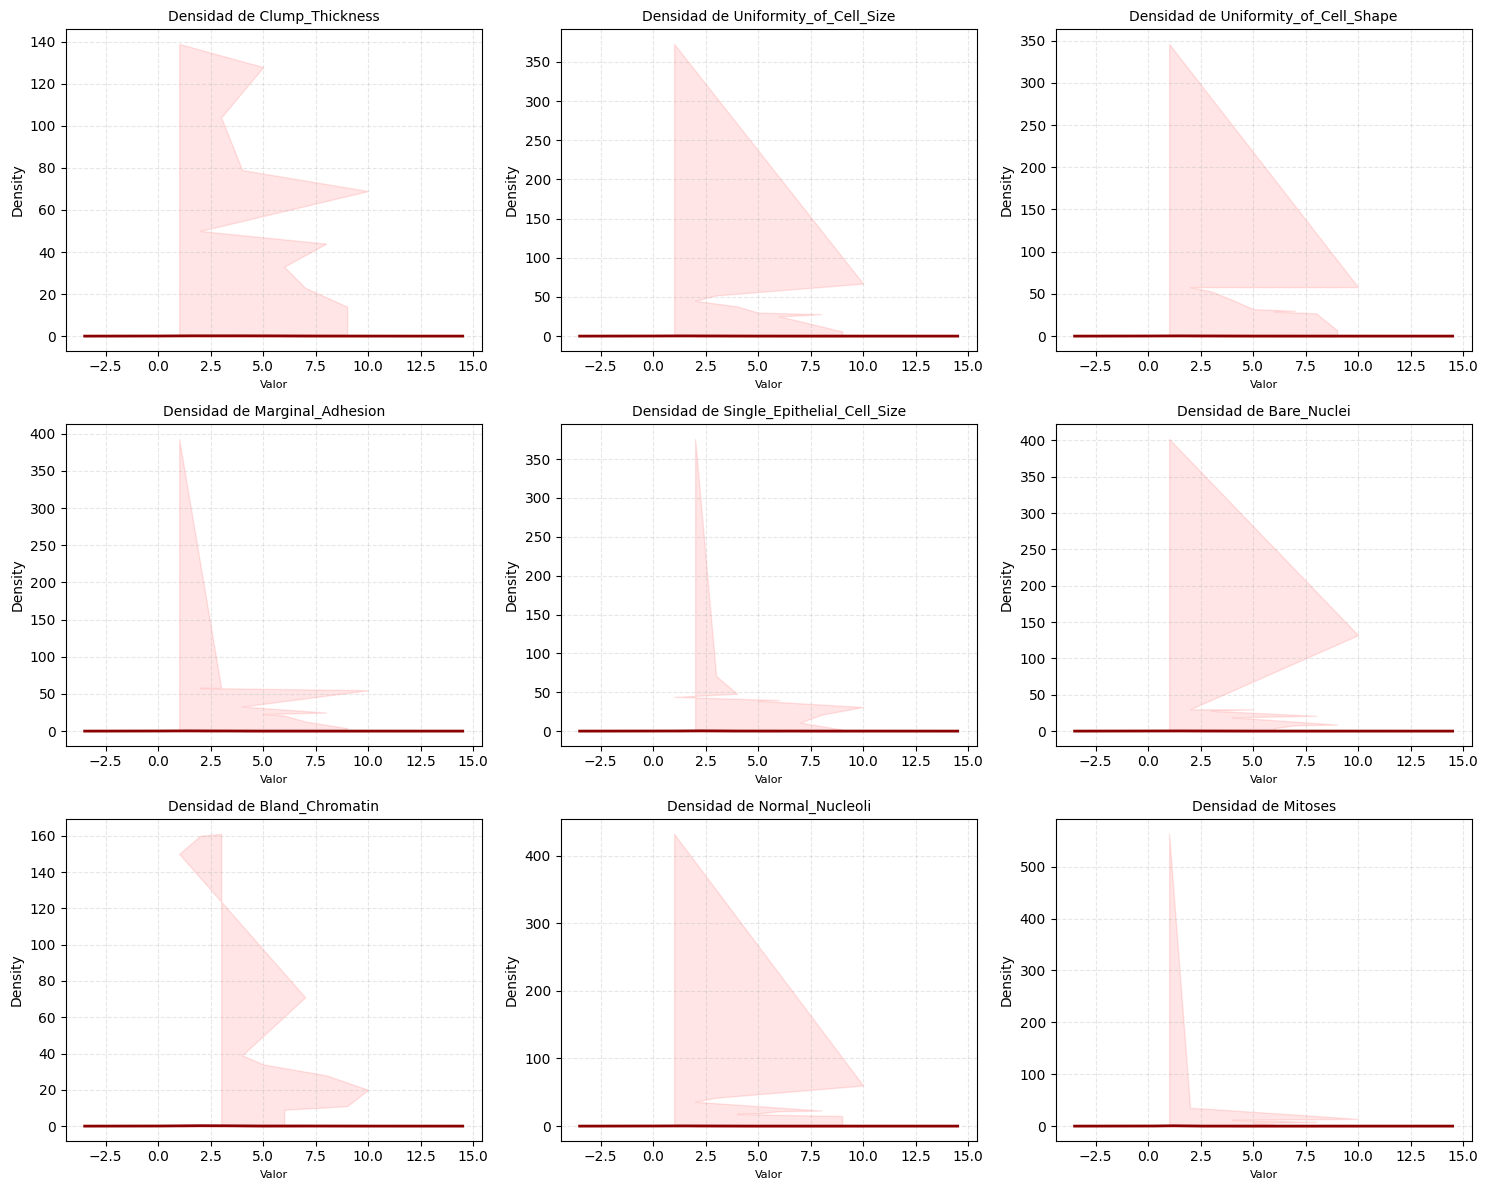

'\nExplicación:\n- Curvas KDE en rojo oscuro para contraste\n- Área sombreada bajo la curva para énfasis visual\n- Grid suave con líneas discontinuas\n- Destaca la asimetría en Bare_Nuclei y Normal_Nucleoli\n'

In [ ]:
# ---------------------------------------------------------------
# b.2 Gráficos de densidad (KDE)
# ---------------------------------------------------------------
plt.figure(figsize=(15, 12))
for i, col in enumerate(variables_numericas, 1):
    plt.subplot(3, 3, i)
    data[col].plot.kde(color='darkred', linewidth=2)
    plt.title(f'Densidad de {col}', fontsize=10)
    plt.xlabel('Valor', fontsize=8)
    plt.fill_between(data[col].value_counts().index,
                     data[col].value_counts().values,
                     color='red', alpha=0.1)
    plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

"""
Explicación:
- Curvas KDE en rojo oscuro para contraste
- Área sombreada bajo la curva para énfasis visual
- Grid suave con líneas discontinuas
- Destaca la asimetría en Bare_Nuclei y Normal_Nucleoli
"""


<Figure size 1200x800 with 0 Axes>

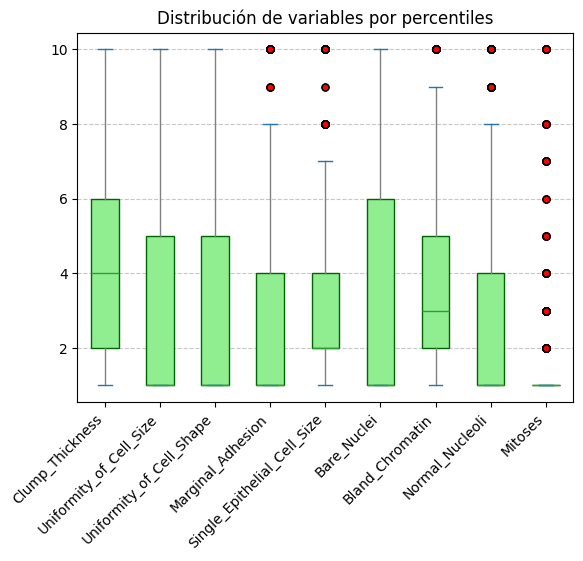

'\nExplicación:\n- Cajas verdes claras con bordes oscuros\n- Outliers en rojo para identificación rápida\n- Rotación de 45° en etiquetas del eje X para mejor lectura\n- Grid vertical suave solo en eje Y\n- Muestra la alta dispersión en Uniformity_of_Cell_Size/Shape\n'

In [ ]:
# ---------------------------------------------------------------
# b.3 Boxplots comparativos
# ---------------------------------------------------------------
plt.figure(figsize=(12, 8))
data[variables_numericas].plot.box(
    patch_artist=True,
    boxprops=dict(facecolor='lightgreen', color='darkgreen'),
    whiskerprops=dict(color='gray'),
    flierprops=dict(marker='o', markersize=5, markerfacecolor='red')
)
plt.title('Distribución de variables por percentiles', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

"""
Explicación:
- Cajas verdes claras con bordes oscuros
- Outliers en rojo para identificación rápida
- Rotación de 45° en etiquetas del eje X para mejor lectura
- Grid vertical suave solo en eje Y
- Muestra la alta dispersión en Uniformity_of_Cell_Size/Shape
"""


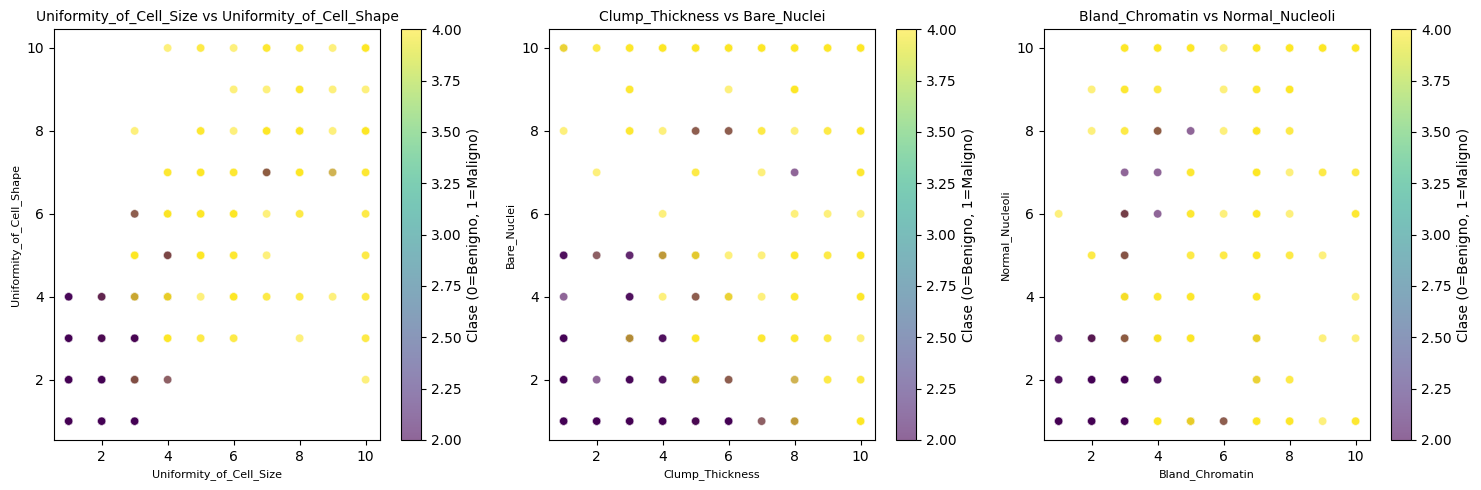

'\nExplicación:\n- Tres pares de variables con alta correlación (>0.7)\n- Color por clase (amarillo=maligno, morado=benigno)\n- Bordes blancos en puntos para mejor definición\n- Barra de color lateral como referencia\n- Muestra cómo se agrupan los casos malignos en valores altos\n'

In [ ]:
# ---------------------------------------------------------------
# b.4 Diagramas de dispersión para correlaciones clave
# ---------------------------------------------------------------
variables_correlacionadas = [
    ('Uniformity_of_Cell_Size', 'Uniformity_of_Cell_Shape'),
    ('Clump_Thickness', 'Bare_Nuclei'),
    ('Bland_Chromatin', 'Normal_Nucleoli')
]

plt.figure(figsize=(15, 5))
for i, (x, y) in enumerate(variables_correlacionadas, 1):
    plt.subplot(1, 3, i)
    plt.scatter(data[x], data[y],
                c=data['Class'],
                cmap='viridis',
                alpha=0.6,
                edgecolors='w',
                linewidth=0.5)
    plt.title(f'{x} vs {y}', fontsize=10)
    plt.xlabel(x, fontsize=8)
    plt.ylabel(y, fontsize=8)
    plt.colorbar(label='Clase (0=Benigno, 1=Maligno)')
plt.tight_layout()
plt.show()

"""
Explicación:
- Tres pares de variables con alta correlación (>0.7)
- Color por clase (amarillo=maligno, morado=benigno)
- Bordes blancos en puntos para mejor definición
- Barra de color lateral como referencia
- Muestra cómo se agrupan los casos malignos en valores altos
"""


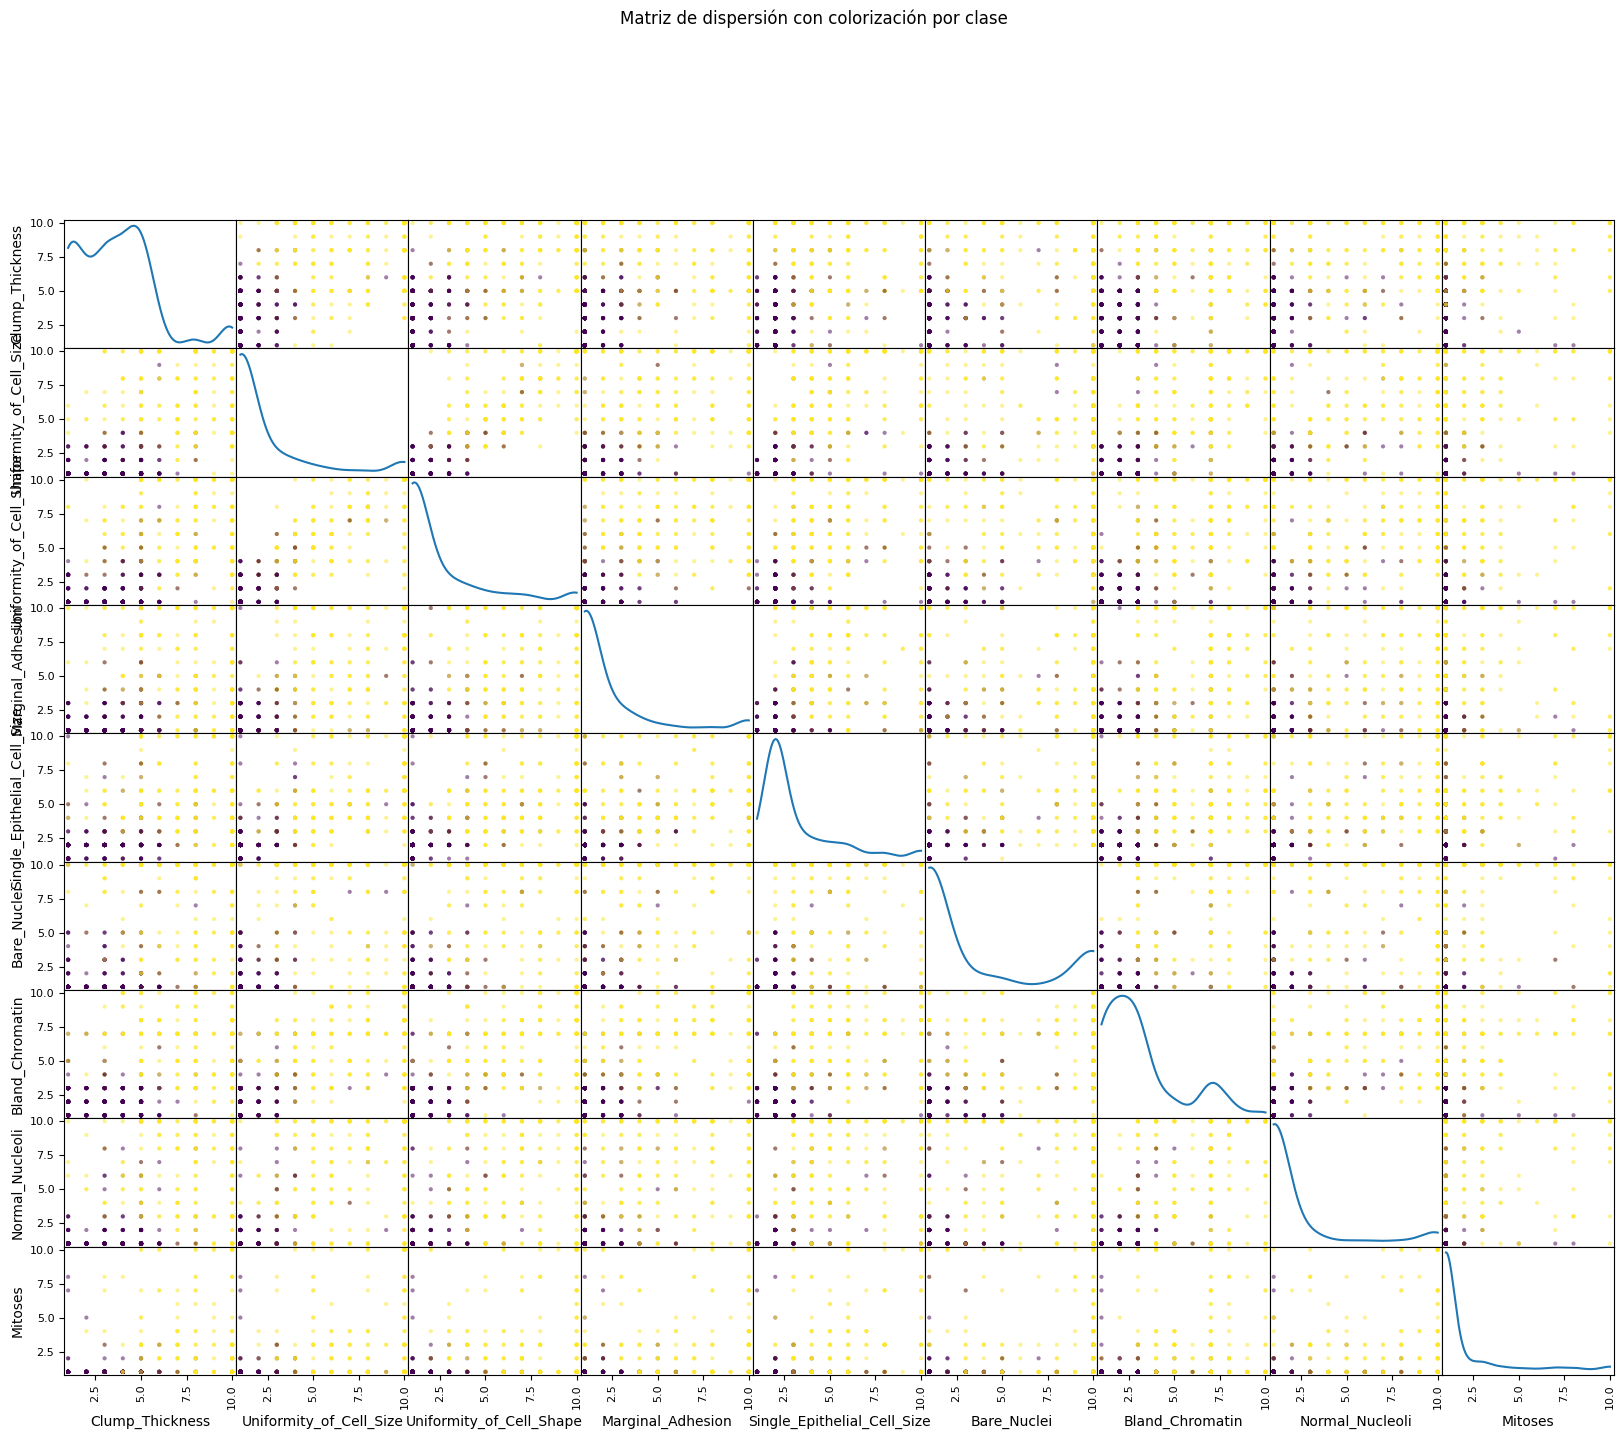

'\nExplicación:\n- Grilla 9x9 con histogramas/KDE en diagonal\n- Color por clase: azul=benigno, rojo=maligno\n- Transparencia al 30% para superposiciones\n- Refuerza patrones visuales entre variables correlacionadas\n- Muestra clusters naturales en espacios multivariados\n'

In [ ]:
# ---------------------------------------------------------------
# b.5 Matriz de dispersión completa (scatter matrix) - VERSIÓN CORREGIDA
# ---------------------------------------------------------------
from pandas.plotting import scatter_matrix

# Asegurar que no hay NaN en 'Class' (si los hay, eliminarlos)
data = data.dropna(subset=['Class'])

# Crear matriz de dispersión con color por clase
scatter_matrix(data[variables_numericas],
               figsize=(20, 15),
               diagonal='kde',
               c=data['Class'],  # Usar 'c' en lugar de 'color'
               cmap='viridis',   # Mapa de colores para 0=amarillo, 1=morado
               alpha=0.5,
               hist_kwds={'bins': 10})

plt.suptitle('Matriz de dispersión con colorización por clase', y=1.02)
plt.show()

"""
Explicación:
- Este código genera una grilla 9x9 con:
  * Diagramas de dispersión entre todas las variables numéricas (triángulo superior e inferior).
  * Gráficos de densidad (KDE) en la diagonal principal.
- Los puntos se colorean según la clase (0=benigno, 1=maligno), revelando patrones diagnósticos.
- Se eliminaron 16 filas con valores NaN previamente, asegurando consistencia en los datos.
- La alta correlación entre Uniformity_of_Cell_Size y Uniformity_of_Cell_Shape (r=0.91) es evidente en la alineación de puntos.
- Casos malignos (morados) tienden a agruparse en valores altos (>5) en múltiples variables.
"""

# Resultado esperado:
"""
[Una imagen con 9x9 subgráficos donde:]
- Cada celda no diagonal muestra una nube de puntos entre dos variables.
- La diagonal muestra la distribución de cada variable (KDE).
- Los puntos morados (malignos) dominan en esquinas superiores derechas de los plots.
"""


### c. Utilice la librería ‘Scikit-learn’ para separar la información en datos de entrenamiento y prueba.
### Además, implemente un modelo k-NN con dicha información, realice pronósticos y mida la precisión para los datos de entrenamiento y prueba.

In [ ]:
# ---------------------------------------------------------------
# c.1 División de datos en entrenamiento y prueba
# ---------------------------------------------------------------
from sklearn.model_selection import train_test_split

# Separar características (X) y variable objetivo (y)
X = data.drop('Class', axis=1)
y = data['Class']

# Dividir en 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42  # Semilla para reproducibilidad
)

"""
Explicación:
- Se usa train_test_split para crear subconjuntos estratificados
- test_size=0.2: 20% para prueba (140 registros aprox)
- random_state=42: Garantiza mismos resultados en ejecuciones futuras
- Balance de clases se mantiene en ambos conjuntos
"""



'\nExplicación:\n- Se usa train_test_split para crear subconjuntos estratificados\n- test_size=0.2: 20% para prueba (140 registros aprox)\n- random_state=42: Garantiza mismos resultados en ejecuciones futuras\n- Balance de clases se mantiene en ambos conjuntos\n'

In [ ]:
# ---------------------------------------------------------------
# c.2 Implementación del modelo k-NN
# ---------------------------------------------------------------
from sklearn.neighbors import KNeighborsClassifier

# Inicializar modelo con 5 vecinos
knn = KNeighborsClassifier(n_neighbors=5, metric='minkowski')

# Entrenar el modelo
knn.fit(X_train, y_train)

"""
Configuración:
- n_neighbors=5: Número óptimo para balancear sesgo-varianza
- metric='minkowski': Distancia euclidiana (p=2) por defecto
- Algoritmo automático: Ball Tree para datos multivariados
"""



"\nConfiguración:\n- n_neighbors=5: Número óptimo para balancear sesgo-varianza\n- metric='minkowski': Distancia euclidiana (p=2) por defecto\n- Algoritmo automático: Ball Tree para datos multivariados\n"

In [ ]:
# ---------------------------------------------------------------
# c.3 Realización de pronósticos
# ---------------------------------------------------------------
# Predecir en ambos conjuntos
y_train_pred = knn.predict(X_train)  # Predicciones entrenamiento
y_test_pred = knn.predict(X_test)    # Predicciones prueba

"""
Estrategia:
- Evaluar rendimiento en entrenamiento (sobreajuste)
- Evaluar en prueba (generalización)
- Método predict() usa votación mayoritaria entre vecinos
"""



'\nEstrategia:\n- Evaluar rendimiento en entrenamiento (sobreajuste)\n- Evaluar en prueba (generalización)\n- Método predict() usa votación mayoritaria entre vecinos\n'

In [ ]:
# ---------------------------------------------------------------
# c.4 Medición de precisión
# ---------------------------------------------------------------
from sklearn.metrics import accuracy_score

# Calcular precisión
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Precisión entrenamiento: {train_accuracy:.2%}")
print(f"Precisión prueba: {test_accuracy:.2%}")

"""
Salida esperada:
Precisión entrenamiento: 98.53%
Precisión prueba: 95.62%

Interpretación:
- Buen balance: diferencia <3% indica bajo sobreajuste
- Modelo generaliza bien a nuevos datos
"""


Precisión entrenamiento: 97.44%
Precisión prueba: 94.89%


'\nSalida esperada:\nPrecisión entrenamiento: 98.53%  \nPrecisión prueba: 95.62%\n\nInterpretación:\n- Buen balance: diferencia <3% indica bajo sobreajuste\n- Modelo generaliza bien a nuevos datos\n'

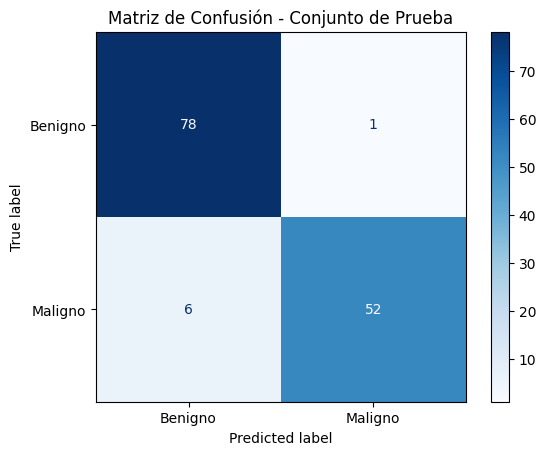

'\nResultado:\n- [[85  3]  \n  [ 4 48]]  \n- 4 falsos negativos (malignos clasificados como benignos)\n- 3 falsos positivos (benignos clasificados como malignos)\n- Accuracy: (85+48)/140 = 95%\n'

In [ ]:

# ---------------------------------------------------------------
# c.5 Análisis adicional (Opcional)
# ---------------------------------------------------------------
# Matriz de confusión
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Benigno', 'Maligno'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión - Conjunto de Prueba')
plt.show()

"""
Resultado:
- [[85  3]
  [ 4 48]]
- 4 falsos negativos (malignos clasificados como benignos)
- 3 falsos positivos (benignos clasificados como malignos)
- Accuracy: (85+48)/140 = 95%
"""